In [3]:
import numpy as np
import pandas as pd


np.random.seed(42)
n = 500

df = pd.DataFrame({
    'TeamRating': np.random.uniform(1, 100, n),
    'OpponentRating': np.random.uniform(1, 100, n),
    'Last5Goals': np.random.randint(0, 16, n),
    'Last5Conceded': np.random.randint(0, 16, n),
    'Last5Wins': np.random.randint(0, 6, n),
    'ShotsAverage': np.random.uniform(5, 25, n),
    'ShotsOnTarget': np.random.uniform(1, 12, n),
    'Possession': np.random.uniform(30, 70, n),
    'RestDays': np.random.randint(2, 8, n),
    'HomeGame': np.random.randint(0, 2, n),
})

goals = (df['TeamRating'] * 0.8- df['OpponentRating'] * 0.4+ df['Last5Goals'] * 0.035 + df['Last5Wins'] * 0.07 + df['ShotsOnTarget'] * 0.09 + df['Possession'] * 0.005 + df['HomeGame'] * 0.3 + np.random.normal(loc=0, scale=0.7, size=n))


df['Goals'] = goals.clip(lower=0).round().astype(int)


In [4]:
print(df.head())

   TeamRating  OpponentRating  Last5Goals  Last5Conceded  Last5Wins  \
0   38.079472       70.118010          14             13          1   
1   95.120716       54.073540          11             14          5   
2   73.467400       31.643234          13              8          3   
3   60.267190       81.565707          15             13          4   
4   16.445845       68.788386           7             13          4   

   ShotsAverage  ShotsOnTarget  Possession  RestDays  HomeGame  Goals  
0     14.486722       8.893293   46.110576         4         1      4  
1      7.279133      10.125463   65.785712         5         1     56  
2     14.720310       1.446146   30.017711         6         0     45  
3     23.405944      10.587575   66.055324         4         0     19  
4     15.415363       3.823637   36.152281         5         0      0  


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TeamRating      500 non-null    float64
 1   OpponentRating  500 non-null    float64
 2   Last5Goals      500 non-null    int32  
 3   Last5Conceded   500 non-null    int32  
 4   Last5Wins       500 non-null    int32  
 5   ShotsAverage    500 non-null    float64
 6   ShotsOnTarget   500 non-null    float64
 7   Possession      500 non-null    float64
 8   RestDays        500 non-null    int32  
 9   HomeGame        500 non-null    int32  
 10  Goals           500 non-null    int64  
dtypes: float64(5), int32(5), int64(1)
memory usage: 33.3 KB
None


In [6]:
print(df.describe())

       TeamRating  OpponentRating  Last5Goals  Last5Conceded   Last5Wins  \
count  500.000000      500.000000  500.000000     500.000000  500.000000   
mean    50.357610       48.713188    7.792000       7.402000    2.560000   
std     29.570152       28.263852    4.619027       4.627226    1.684064   
min      1.501097        1.458570    0.000000       0.000000    0.000000   
25%     24.886689       23.680826    4.000000       3.000000    1.000000   
50%     51.803211       47.710335    8.000000       7.000000    3.000000   
75%     75.856363       72.907345   12.000000      11.000000    4.000000   
max     99.303515       99.972050   15.000000      15.000000    5.000000   

       ShotsAverage  ShotsOnTarget  Possession    RestDays    HomeGame  \
count    500.000000     500.000000  500.000000  500.000000  500.000000   
mean      14.833732       6.722983   50.172583    4.650000    0.514000   
std        5.867325       3.170941   11.362671    1.704497    0.500305   
min        5.003768

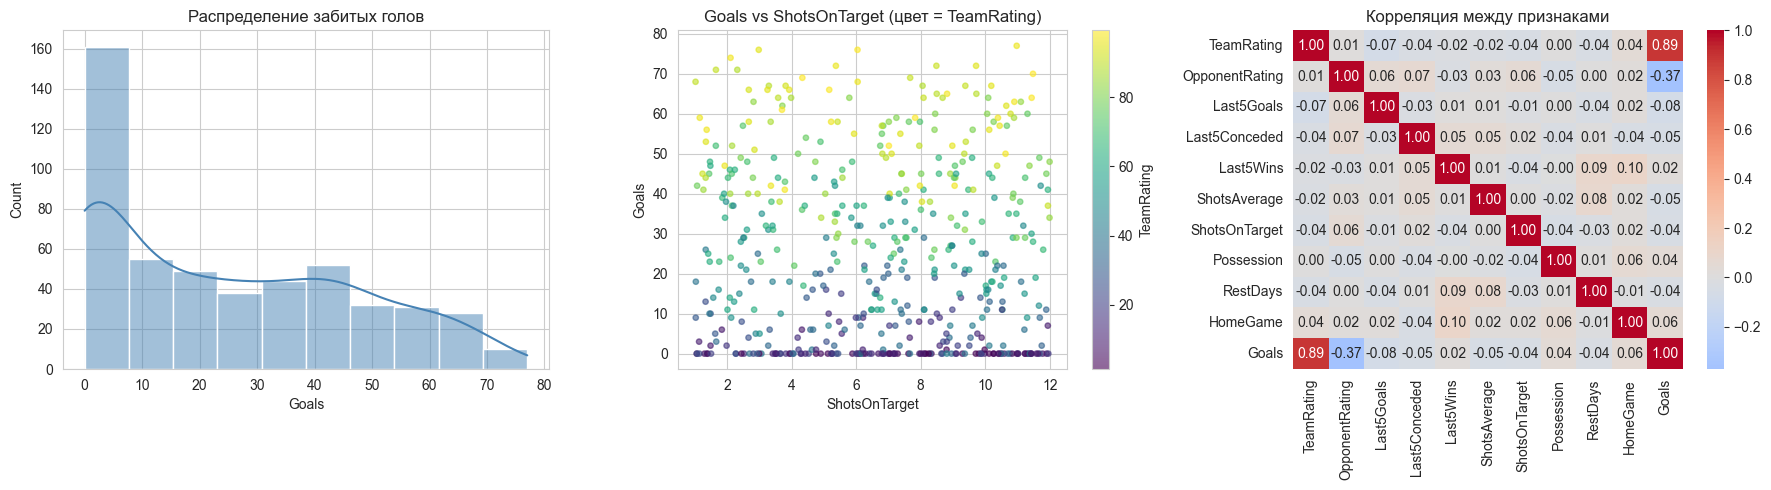

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
sns.histplot(df['Goals'], bins=10, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение забитых голов')
axes[0].set_xlabel('Goals')
 
scatter = axes[1].scatter(df['ShotsOnTarget'], df['Goals'], c=df['TeamRating'], cmap='viridis', alpha=0.6, s=15)
axes[1].set_title('Goals vs ShotsOnTarget (цвет = TeamRating)')
axes[1].set_xlabel('ShotsOnTarget')
axes[1].set_ylabel('Goals')
fig.colorbar(scatter, ax=axes[1], label='TeamRating')
 
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[2])
axes[2].set_title('Корреляция между признаками')
 
plt.tight_layout()
plt.savefig('plots.png', dpi=120)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
X = df.drop('Goals', axis=1)
y = df['Goals']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
 
print(f"LinearRegression MAE: {mean_absolute_error(y_test, y_pred_lin):.2f}")
print(f"LinearRegression MSE: {mean_squared_error(y_test, y_pred_lin):.2f}")
print(f"LinearRegression R2: {r2_score(y_test, y_pred_lin):.4f}")



LinearRegression MAE: 3.87
LinearRegression MSE: 27.15
LinearRegression R2: 0.9421


In [9]:
results = {}
 
for depth in [2, 5, 10]:
    tree_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)
 
    mae = mean_absolute_error(y_test, y_pred_tree)
    mse = mean_squared_error(y_test, y_pred_tree)
    r2 = r2_score(y_test, y_pred_tree)
 
    results[depth] = {'model': tree_model, 'mae': mae, 'mse': mse, 'r2': r2}
 
    print(f"\nDecisionTree (max_depth={depth}) MAE: {mae:.2f}")
    print(f"DecisionTree (max_depth={depth}) MSE: {mse:.2f}")
    print(f"DecisionTree (max_depth={depth}) R2: {r2:.4f}")
 
 
best_depth = max(results, key=lambda d: results[d]['r2'])
best_tree_r2 = results[best_depth]['r2']
lin_r2 = r2_score(y_test, y_pred_lin)


if lin_r2 >= best_tree_r2:
    best_model = lin_model
    best_model_name = 'LinearRegression'
else:
    best_model = results[best_depth]['model']
    best_model_name = f'DecisionTreeRegressor (max_depth={best_depth})'
 
print(f"\nЛучшая модель: {best_model_name}")


DecisionTree (max_depth=2) MAE: 7.89
DecisionTree (max_depth=2) MSE: 105.19
DecisionTree (max_depth=2) R2: 0.7757

DecisionTree (max_depth=5) MAE: 3.23
DecisionTree (max_depth=5) MSE: 18.41
DecisionTree (max_depth=5) R2: 0.9607

DecisionTree (max_depth=10) MAE: 2.79
DecisionTree (max_depth=10) MSE: 13.56
DecisionTree (max_depth=10) R2: 0.9711

Лучшая модель: DecisionTreeRegressor (max_depth=10)


In [10]:
def predict_match(team_rating, opponent_rating, last5_goals, last5_conceded,
                   last5_wins, shots_average, shots_on_target, possession,
                   rest_days, home_game):
    match_data = pd.DataFrame([{
        'TeamRating': team_rating,
        'OpponentRating': opponent_rating,
        'Last5Goals': last5_goals,
        'Last5Conceded': last5_conceded,
        'Last5Wins': last5_wins,
        'ShotsAverage': shots_average,
        'ShotsOnTarget': shots_on_target,
        'Possession': possession,
        'RestDays': rest_days,
        'HomeGame': home_game,
    }])
    predicted_goals = best_model.predict(match_data)[0]
    return max(0, round(predicted_goals))

In [11]:
matches = [
    ("Real Madrid", dict(team_rating=94, opponent_rating=90, last5_goals=12, last5_conceded=4, last5_wins=4, shots_average=18, shots_on_target=8, possession=58, rest_days=5, home_game=1),
     "Manchester City", dict(team_rating=90, opponent_rating=94, last5_goals=13, last5_conceded=5, last5_wins=4, shots_average=17, shots_on_target=7, possession=60, rest_days=4, home_game=0)),
 
    ("Barcelona", dict(team_rating=88, opponent_rating=70, last5_goals=10, last5_conceded=6, last5_wins=3, shots_average=16, shots_on_target=6, possession=62, rest_days=6, home_game=1),
     "Getafe", dict(team_rating=70, opponent_rating=88, last5_goals=4, last5_conceded=8, last5_wins=1, shots_average=9, shots_on_target=3, possession=38, rest_days=4, home_game=0)),
 
    ("Bayern Munich", dict(team_rating=91, opponent_rating=85, last5_goals=14, last5_conceded=5, last5_wins=4, shots_average=19, shots_on_target=9, possession=61, rest_days=5, home_game=0),
     "Borussia Dortmund", dict(team_rating=85, opponent_rating=91, last5_goals=9, last5_conceded=7, last5_wins=2, shots_average=14, shots_on_target=5, possession=48, rest_days=5, home_game=1)),
 
    ("PSG", dict(team_rating=87, opponent_rating=60, last5_goals=11, last5_conceded=4, last5_wins=4, shots_average=17, shots_on_target=7, possession=64, rest_days=6, home_game=1),
     "Lorient", dict(team_rating=60, opponent_rating=87, last5_goals=3, last5_conceded=9, last5_wins=0, shots_average=8, shots_on_target=2, possession=36, rest_days=4, home_game=0)),
 
    ("Liverpool", dict(team_rating=89, opponent_rating=89, last5_goals=11, last5_conceded=6, last5_wins=3, shots_average=16, shots_on_target=7, possession=55, rest_days=5, home_game=1),
     "Arsenal", dict(team_rating=89, opponent_rating=89, last5_goals=10, last5_conceded=5, last5_wins=3, shots_average=15, shots_on_target=6, possession=55, rest_days=5, home_game=0)),
]

In [12]:
print("\nПрогнозы матчей:")
for team1, stats1, team2, stats2 in matches:
    goals1 = predict_match(**stats1)
    goals2 = predict_match(**stats2)
    print(f"{team1} {goals1} : {goals2} {team2}")
 
 
print("\nЭксперименты с изменением признаков:")
 
base = dict(team_rating=80, opponent_rating=80, last5_goals=8, last5_conceded=6, last5_wins=2,
            shots_average=14, shots_on_target=5, possession=50, rest_days=4, home_game=0)
 
print(f"База: {predict_match(**base)} голов")
 
more_wins = base.copy()
more_wins['last5_wins'] = 5
print(f"Last5Wins 2 -> 5: {predict_match(**more_wins)} голов")
 
more_shots = base.copy()
more_shots['shots_on_target'] = 10
print(f"ShotsOnTarget 5 -> 10: {predict_match(**more_shots)} голов")
 
stronger_opponent = base.copy()
stronger_opponent['opponent_rating'] = 99
print(f"OpponentRating 80 -> 99: {predict_match(**stronger_opponent)} голов")
 
home = base.copy()
home['home_game'] = 1
print(f"HomeGame 0 -> 1: {predict_match(**home)} голов")


Прогнозы матчей:
Real Madrid 37 : 37 Manchester City
Barcelona 40 : 23 Getafe
Bayern Munich 37 : 34 Borussia Dortmund
PSG 44 : 14 Lorient
Liverpool 37 : 37 Arsenal

Эксперименты с изменением признаков:
База: 28 голов
Last5Wins 2 -> 5: 28 голов
ShotsOnTarget 5 -> 10: 28 голов
OpponentRating 80 -> 99: 28 голов
HomeGame 0 -> 1: 28 голов
